# ASOS Product Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('products_asos.csv')

## Data Overview

In [36]:
df.shape

(30845, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30845 entries, 0 to 30844
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          30827 non-null  object 
 1   name         30827 non-null  object 
 2   size         30827 non-null  object 
 3   category     30827 non-null  object 
 4   price        30827 non-null  object 
 5   color        30827 non-null  object 
 6   sku          30827 non-null  float64
 7   description  30827 non-null  object 
 8   images       30827 non-null  object 
dtypes: float64(1), object(8)
memory usage: 2.1+ MB


In [9]:
df.describe(include='all')

,url,name,size,category,price,color,sku,description,images
count,30827,30827,30827,30827,30827,30827,3.082700e+04,30827,30827
unique,30468,29493,5073,29492,880,3636,NaN,29971,29972
top,https://www.asos.com/calvin-klein-jeans/calvin...,ASOS 4505 icon performance t-shirt,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14,UK 16,UK 18",ASOS 4505 icon performance t-shirt,30.00,BLACK,NaN,[{'Product Details': 'Coats & Jackets by Bergh...,['https://images.asos-media.com/products/collu...
freq,2,7,2912,7,706,3289,NaN,5,5
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.154976e+08,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,2.259336e+07,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,4.010200e+05,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.173468e+08,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.199234e+08,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.228726e+08,NaN,NaN


In [10]:
df[df.isnull().any(axis=1)]

,url,name,size,category,price,color,sku,description,images
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df['category'].unique()

array(['New Look trench coat in camel',
       'Stradivarius double breasted wool coat in grey',
       'JDY oversized trench coat in stone', ...,
       'ASYOU layered t-shirt dress with focus graphic in washed black',
       'Miss Selfridge Petite rib knit frill hem funnel dress with heart buttons in black',
       '& Other Stories plisse mesh midi dress in black and white print'],
      dtype=object)

## Data Prep

In [3]:
df['price']=pd.to_numeric(df['price'],errors='coerce') #to_numeric forces numeric values in the column and coerce throws out NaNs for errors

df =df.dropna(subset=['price'])

In [4]:
print(f"Data Loaded: {len(df)} rows") #to display rows being uploaded/modified

df.head()

Data Loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [5]:
df['description'] = df['description'].str.replace(
    r'([a-z])([A-Z])',
    r'\1 \2',
    regex=True
)

#Separating all words in the description that show follow the patter lowercaseUPPERCASE
#Capturing then with ([a-z])([A-Z]) and then breaks them adding a space \1=([a-z]) \2=([A-Z])
#regex=true is to tell py to treat as a regular expression and not literal text, so that it does not look for extractly the characters it was told

In [6]:
df['brand_part'] = df['description'].str.split('by ').str[1]
#Splits the description after the word 'by' to get the brand and selects that section [1]

In [7]:
df['brand'] = df['brand_part'].str.extract(
    r'^([A-Z][A-Za-z]*(?:\s[A-Z][A-Za-z]*)*)'
)
#Extracts the brand name by looking up the patter Upper Case letter, followed by upper or lower case and any repeated values = [A-Z][A-Za-z]*
#Then, groups but doesn't capture '?:' a space \s and the same pattern [A-Z][A-Za-z]* and it looks for repeated words like it with a final *

In [8]:
df['brand'] = df['brand'].str.split().str[:2].str.join(' ')
#Gets the brand column into separate words .split(), then keeps the first two elements .str[:2]
#Then joins the two elements with a space .join(' ')

In [9]:
df[['description','brand_part','brand']].head(20) #Inspecting results

,description,brand_part,brand
0,[{'Product Details': 'Coats & Jackets by New L...,New Look Low-key layering Notch collar Button ...,New Look
1,[{'Product Details': 'Coats & Jackets by New L...,New Look Low-key layering Notch collar Button ...,New Look
2,[{'Product Details': 'Coats & Jackets by New L...,New Look Low-key layering Notch collar Button ...,New Look
3,[{'Product Details': 'Coats & Jackets by New L...,New Look Low-key layering Notch collar Button ...,New Look
4,[{'Product Details': 'Coats & Jackets by Strad...,Stradivarius Jacket upgrade: check Notch colla...,Stradivarius Jacket
5,[{'Product Details': 'Coats & Jackets by Strad...,Stradivarius Jacket upgrade: check Notch colla...,Stradivarius Jacket
6,[{'Product Details': 'Coats & Jackets by Strad...,Stradivarius Jacket upgrade: check Notch colla...,Stradivarius Jacket
7,[{'Product Details': 'Coats & Jackets by Strad...,Stradivarius Jacket upgrade: check Notch colla...,Stradivarius Jacket
8,[{'Product Details': 'Coats & Jackets by JDYLo...,JDYLow-key layering Notch collar Button placke...,JDYLow
9,[{'Product Details': 'Coats & Jackets by JDYLo...,JDYLow-key layering Notch collar Button placke...,JDYLow


In [44]:
brand_counts = df['brand'].value_counts().reset_index()
brand_counts.columns = ['brand','count']
brand_counts.to_csv("brand_review.csv", index=False)
#Exports brand and count columns as a csv

In [10]:
brand_lookup = pd.read_csv("brand_review_lookup.csv")
#Once csv is reviewed and brands are normalized, the file is uploaded and inspected

In [11]:
brand_lookup.head()

,brand,count,Brand_New
0,Abercrombie,49,Abercrombie
1,Accessorize Daywear,1,Accessorize
2,Accessorize Dreaming,4,Accessorize
3,Accessorize Exclusive,2,Accessorize
4,Accessorize Love,1,Accessorize


In [12]:
df=df.merge(brand_lookup[['brand','Brand_New']],on='brand',how='left')
#merges the column brand from the original df and the column Brand_New created in the csv after inspection
#they are merged on the column brand and left keeps all the original df

In [48]:
df.head()

,url,name,size,category,price,color,sku,description,images,brand_part,brand,Brand_New
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look Low-key layering Notch collar Button ...,New Look,New Look
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look Low-key layering Notch collar Button ...,New Look,New Look
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look Low-key layering Notch collar Button ...,New Look,New Look
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look Low-key layering Notch collar Button ...,New Look,New Look
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,Stradivarius Jacket upgrade: check Notch colla...,Stradivarius Jacket,Stradivarius


In [13]:
df['brand']=df['Brand_New'].fillna(df['brand'])
df=df.drop(columns='Brand_New')

In [14]:
df.head()

,url,name,size,category,price,color,sku,description,images,brand_part,brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look Low-key layering Notch collar Button ...,New Look
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look Low-key layering Notch collar Button ...,New Look
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look Low-key layering Notch collar Button ...,New Look
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look Low-key layering Notch collar Button ...,New Look
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,Stradivarius Jacket upgrade: check Notch colla...,Stradivarius


In [15]:
brand_counts=df['brand'].value_counts()
print(brand_counts)

brand
ASOS              4844
Topshop           1136
New Look           471
River Island       467
Miss Selfridge     429
                  ... 
RVCA Pool            1
Gossard              1
BAD SOCIETY          1
Madewell All         1
Gbemi                1
Name: count, Length: 244, dtype: int64


## StockOut Analysis

In [22]:
def calculate_revenue_gap(size_str): #Defining a function to analyze the revenue gap because of stockouts. Size_str is the value for the 'size' column in one row
    if not isinstance(size_str, str): #checks data type, meaning if size_str is not a string 'str'.
        return 0, 0.0

    sizes=size_str.split(',') #splits sizes and puts them in a list
    total_sizes=len(sizes) #counts number of elements in the list

    out_of_stock_count = size_str.count('Out of stock') #counts how many times 'out of stock' appears on the list

    rate=out_of_stock_count/total_sizes if total_sizes > 0 else 0.0 #percentage of sizes unavailable for each row

    return out_of_stock_count, rate

metrics = df['size'].apply(lambda x: calculate_revenue_gap(x)) #applies the function to all rows in 'size'. lambda could be spared since it is a one,argument function

df['Stockout_Count']=[x[0] for x in metrics] #metrics stores results like these [(2, 0.5), (1, 0.25), (0, 0.0)], x[0] takes the first result and puts it in the stockout column
df['Stockout_Rate']=[x[1] for x in metrics] #x[1] takes the second result and puts it in the rate column

df['Lost_Revenue'] = df['price']*df['Stockout_Count'] #missing sizes are lost sales, so this multiplies price x stockout

cols=['brand','name','price','Stockout_Count','Lost_Revenue'] #defines columns to display
print(df.sort_values(by='Lost_Revenue',ascending=False).head(5)[cols]) #prints the table


            brand                                               name  price  \
1346      Barbour               Barbour Beadnell wax jacket in black  219.0   
1282      Barbour  Barbour x ASOS exclusive Stephanie wax parka i...  279.0   
1435   All Saints      AllSaints Elora leather biker jacket in black  319.0   
12738     Topshop  Topshop premium real leather collared zip thro...  260.0   
1300         ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   

       Stockout_Count  Lost_Revenue  
1346                9        1971.0  
1282                7        1953.0  
1435                6        1914.0  
12738               7        1820.0  
1300                7        1540.0  


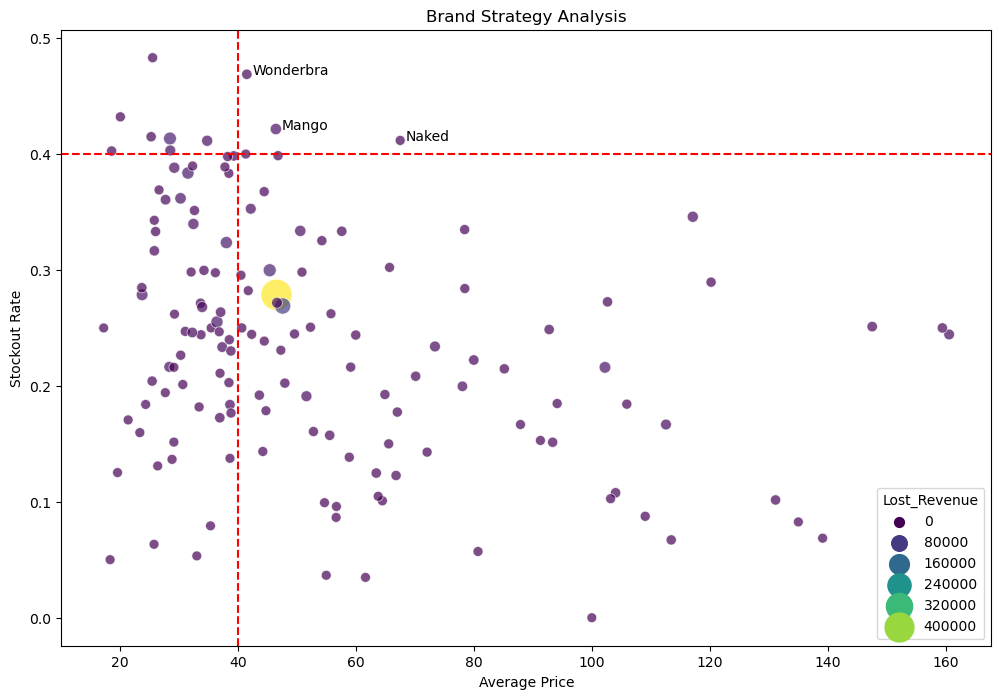

In [27]:

#aggregates data by brand and then defines the measure for each of the columns 'price mean', 'sum of lost rev', etc.
brand_strategy = df.groupby('brand').agg({
    'price':'mean',
    'Stockout_Rate':'mean',
    'Lost_Revenue':'sum',
    'name':'count'
}).reset_index() #converts the grouped column from index back to regular column

brand_strategy=brand_strategy[brand_strategy['name']>10] #removes brands with too few products from the lineup

#creates a scatterplot, where each dot represents a brand. The X axis is the avg price and the Y axis is the stockout rate
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    size='Lost_Revenue',
    hue='Lost_Revenue',
    sizes=(50,500),
    alpha=0.7,
    palette='viridis'
)

#identifies winner brands based on two conditions: the avg price is high and their stockout rate is also high because they are frequently sold
winners=brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout_Rate']>0.4)
]

#loops through the winner brands and adds labels. '+1' is to move the labels a bit higher
for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price']+1,
        winners.iloc[i]['Stockout_Rate'],
        winners.iloc[i]['brand']
    )

#adds titles and creates strategic lines around the parameters for winner brands established earlier
plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red',linestyle='--')
plt.axhline(y=0.4, color='red',linestyle='--')
plt.show()


## Key Insights

1. The brand portfolio is concentrated in the mid-price segment (<$40 average price).
2. Stockout rates typically range between 10–30%, indicating moderate but persistent availability issues.
3. A small number of brands generate disproportionately high lost revenue due to stockouts.
4. Premium brands with high stockout rates represent the largest revenue recovery opportunity.
5. Inventory optimization should prioritize high-price brands with elevated stockout rates, as they produce the greatest financial impact.

## Recommendations

1. Brands located in the high-price and high-stockout quadrant represent the larges revenue recovery opportunity.
   - Increase safety stock
   - Shorten the replenishment cycle
   - Improve demand forecasting for high-value products
  
2. Brands showing elevated stockout rates regardless of price may suffer from supply chain inefficiencies rather than demand issues.
   - Review supplier lead times and reliability.
   - Evaluate reorder thresholds and inventory policies.
   - Identify whether warehouse or distribution bottlenecks contribute to stockouts.

3. Brands with higher prices but lower stockout rates appear to have inventory levels aligned with demand.
   - Maintain current forecasting and replenishment practices.
   - Monitor stockout trends to ensure performance remains stable.


4. Brands with low prices and low lost revenue impact contribute less to overall revenue loss when stockouts occur.
   - Consider prioritizing warehouse capacity and replenishment resources toward higher-impact brands.
   - Review whether some low-impact brands carry excess inventory.

5. To prevent revenue loss proactively, stockout metrics should be monitored regularly.
   - Track stockout rate by brand as a key performance indicator.
   - Implement automated alerts for brands exceeding acceptable stockout thresholds.
   - Periodically review lost revenue metrics to identify emerging risks.


## Strategic takeaway

The analysis indicates that lost revenue from stockouts is concentrated among a small group of brands, particularly those with higher average prices and elevated stockout rates. Focusing inventory optimization efforts on these brands offers the most effective opportunity to recover lost revenue and improve overall product availability.